# Project 02 - The First Day as a Junior Data Analyst

Input: `cleaned_dataset.xlsx`, the output of Project 01.

Before running: put that file in the same folder as this notebook. If the file is a .csv instead, change `file_name` below.

Note on sample size: this dataset has around 60 customers. Several groups used in this analysis (e.g. "At Risk" customers, or a single city) end up with only 5-15 people. Conclusions drawn from that few data points are directional, not statistically proven - this is flagged wherever it matters, not just at the end.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_name = 'cleaned_dataset.xlsx'
df = pd.read_excel(file_name)
df.shape

(60, 17)

## Quick re-check

Even though this data was already cleaned in Project 01, re-checking it here too before building anything on top of it.

In [2]:
df.isna().sum().sum()

0

In [3]:
df.duplicated(subset='customer_id').sum()

0

In [4]:
df.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1030.500000,43.700000,17.383333,213.156500,3381.569167,198.600000,4.183333,2.983333
std,17.464249,13.946994,10.149880,130.509923,3227.321404,97.843043,2.683861,1.431979
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1015.750000,31.750000,10.750000,108.137500,1167.035000,134.250000,2.000000,2.000000
50%,1030.500000,45.000000,17.000000,165.435000,2164.620000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,24.500000,324.107500,4213.117500,273.750000,7.000000,4.000000
max,1060.000000,65.000000,35.000000,449.810000,14354.340000,365.000000,8.000000,5.000000


## Looking at the numbers before anything else

Checking how each numeric column is distributed before jumping into specific questions.

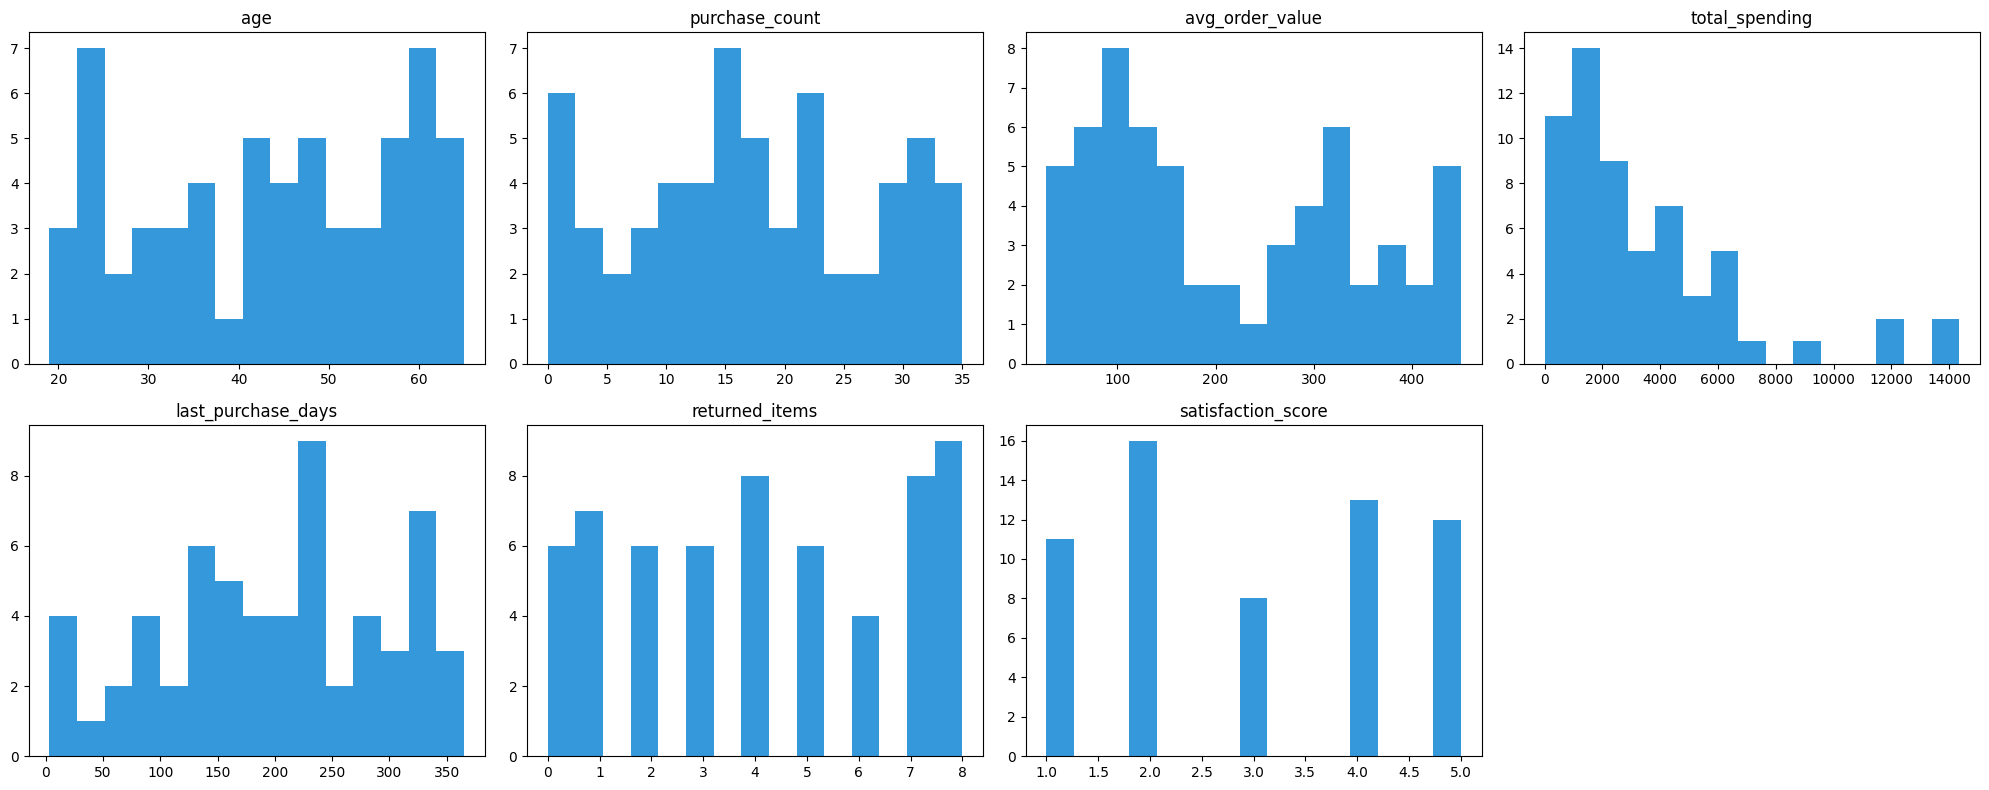

In [5]:
numeric_cols = ['age', 'purchase_count', 'avg_order_value', 'total_spending',
                'last_purchase_days', 'returned_items', 'satisfaction_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=15, color='#3498db')
    axes[i].set_title(col)
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig('distributions.png', dpi=120)
plt.show()

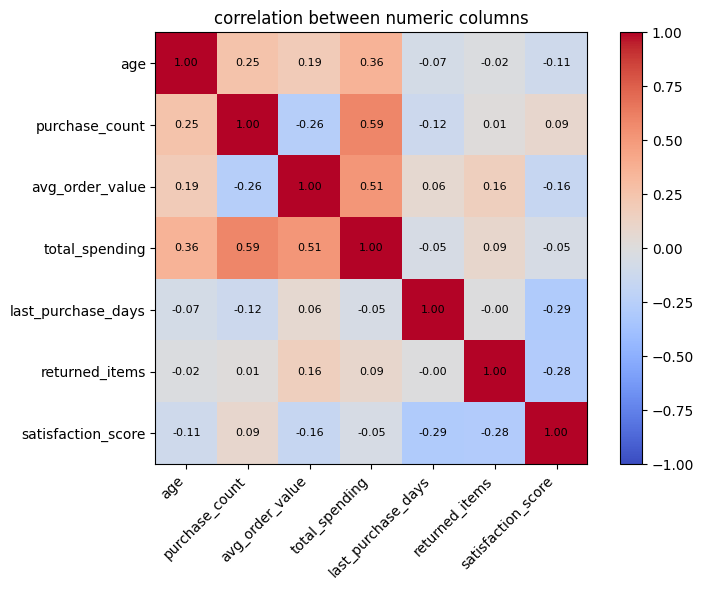

In [6]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('correlation between numeric columns')
plt.tight_layout()
plt.savefig('correlation.png', dpi=120)
plt.show()

## 1. Business Overview - Key KPIs

In [7]:
total_customers = len(df)
total_revenue = df['total_spending'].sum()
avg_order_value = df['avg_order_value'].mean()
avg_satisfaction = df['satisfaction_score'].mean()
avg_purchases = df['purchase_count'].mean()
discount_pct = (df['discount_used'] == True).mean() * 100
avg_returns = df['returned_items'].mean()

print('total customers:', total_customers)
print('total revenue:', round(total_revenue, 2))
print('avg order value:', round(avg_order_value, 2))
print('avg purchases per customer:', round(avg_purchases, 1))
print('avg satisfaction (1-5):', round(avg_satisfaction, 2))
print('% who used a discount:', round(discount_pct, 1))
print('avg returned items:', round(avg_returns, 1))

total customers: 60
total revenue: 202894.15
avg order value: 213.16
avg purchases per customer: 17.4
avg satisfaction (1-5): 2.98
% who used a discount: 43.3
avg returned items: 4.2


## 2. Best City for the Next Marketing Campaign

In [8]:
city_stats = df.groupby('city').agg(
    customers=('customer_id', 'count'),
    total_revenue=('total_spending', 'sum'),
    avg_spending=('total_spending', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).round(1).sort_values('avg_spending', ascending=False)
city_stats

,customers,total_revenue,avg_spending,avg_satisfaction
city,,,,
Isfahan,5,21975.3,4395.1,4.4
Mashhad,11,43197.6,3927.1,2.9
Karaj,7,26189.8,3741.4,2.9
Shiraz,6,20715.9,3452.7,2.0
Rasht,5,15168.5,3033.7,2.6
Tabriz,12,36192.5,3016.0,3.0
Ahvaz,8,23384.8,2923.1,3.5
Tehran,6,16069.7,2678.3,2.7


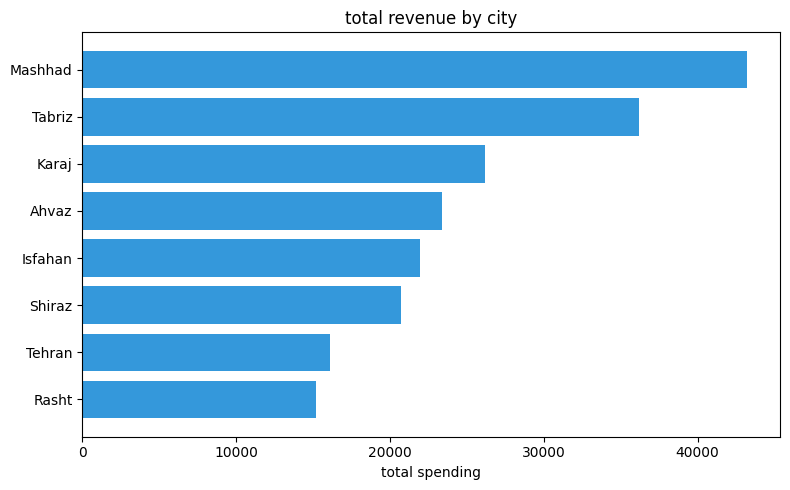

In [9]:
city_rev = df.groupby('city')['total_spending'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(city_rev.index, city_rev.values, color='#3498db')
ax.set_title('total revenue by city')
ax.set_xlabel('total spending')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('city_revenue.png', dpi=120)
plt.show()

Picking a city that performs well on more than one metric - not just total revenue, which is partly a function of having more customers there, but also average spending and satisfaction per person. If the recommended city has a small customer count, that's stated explicitly rather than treated as a bigger finding than it is.

## 3. Customer Segmentation (RFM)

Using a common approach called RFM - scoring each customer on Recency (how long since they bought), Frequency (how often), and Monetary (how much). Adding the three scores gives a rough value ranking.

In [10]:
df['r_score'] = pd.qcut(df['last_purchase_days'], 4, labels=[4, 3, 2, 1]).astype(int)
df['f_score'] = pd.qcut(df['purchase_count'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
df['m_score'] = pd.qcut(df['total_spending'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
df['rfm_score'] = df['r_score'] + df['f_score'] + df['m_score']

def get_segment(row):
    if row['rfm_score'] >= 10:
        return 'Champion'
    elif row['rfm_score'] >= 8:
        return 'Loyal'
    elif row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At Risk'
    elif row['r_score'] <= 2:
        return 'Lost'
    else:
        return 'New / Low-Value'

df['segment'] = df.apply(get_segment, axis=1)
df['segment'].value_counts()

segment
Loyal              19
Champion           14
New / Low-Value    12
Lost               11
At Risk             4
Name: count, dtype: int64

In [11]:
df.groupby('segment')[['total_spending', 'satisfaction_score']].mean().round(2)

,total_spending,satisfaction_score
segment,,
At Risk,2036.93,2.00
Champion,7111.34,3.14
Lost,1121.11,2.36
Loyal,3601.06,3.21
New / Low-Value,1202.95,3.33


## 4. Top 10 Customers for a Loyalty Program

In [12]:
top10 = df.sort_values('rfm_score', ascending=False).head(10)
top10[['customer_id', 'first_name', 'city', 'total_spending', 'purchase_count', 'last_purchase_days', 'rfm_score']]

,customer_id,first_name,city,total_spending,purchase_count,last_purchase_days,rfm_score
56,1057,Maryam,Ahvaz,13532.74,31,82,12
43,1044,Mina,Shiraz,14354.34,33,165,11
3,1004,Sina,Mashhad,6121.45,23,40,11
39,1040,Amir,Tehran,2188.86,34,126,11
32,1033,Neda,Tabriz,5521.20,24,112,11
13,1014,Reza,Tabriz,3353.89,31,97,11
11,1012,Arash,Mashhad,11731.50,27,224,10
16,1017,Parsa,Ahvaz,3239.40,30,135,10
46,1047,Arash,Tabriz,5080.01,23,180,10
44,1045,Maryam,Rasht,3871.92,24,132,10


In [13]:
pct_of_revenue = top10['total_spending'].sum() / total_revenue * 100
print(f'these 10 customers = {pct_of_revenue:.1f}% of total revenue')

these 10 customers = 34.0% of total revenue


Selection based on `rfm_score` rather than raw spending alone, so a customer who made one large purchase and never returned doesn't outrank someone who buys consistently.

## 5. Churn Risk - Customers Who Might Leave

In [14]:
at_risk = df[df['segment'] == 'At Risk'].sort_values('total_spending', ascending=False)
lost = df[df['segment'] == 'Lost']

print('at risk:', len(at_risk))
print('already lost:', len(lost))
at_risk[['customer_id', 'first_name', 'city', 'purchase_count', 'total_spending', 'last_purchase_days']]

at risk: 4
already lost: 11


,customer_id,first_name,city,purchase_count,total_spending,last_purchase_days
48,1049,Ali,Mashhad,23,2140.38,357
33,1034,Maryam,Tabriz,29,2117.00,280
17,1018,Ali,Shiraz,18,1974.60,257
30,1031,Zahra,Tehran,18,1915.74,261


"At Risk" customers previously bought frequently but haven't purchased in a while - the best target for a win-back campaign, since they've already shown interest. "Lost" customers never had much purchase frequency to begin with, so lower priority.

## 6. Discount Users vs. Non-Users

In [15]:
discount_comparison = df.groupby('discount_used').agg(
    customers=('customer_id', 'count'),
    avg_total_spending=('total_spending', 'mean'),
    avg_purchase_count=('purchase_count', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_returned_items=('returned_items', 'mean')
).round(2)
discount_comparison

,customers,avg_total_spending,avg_purchase_count,avg_order_value,avg_satisfaction,avg_returned_items
discount_used,,,,,,
False,34,3736.74,17.29,220.70,2.76,4.26
True,26,2917.11,17.50,203.29,3.27,4.08


In [16]:
corr_discount = df['discount_used'].astype(int).corr(df['satisfaction_score'])
print('correlation with satisfaction:', round(corr_discount, 2))

correlation with satisfaction: 0.18


Looking at more than just total spending gives a fuller picture. Worth checking specifically:
- **avg_purchase_count**: if this is close to the same for both groups, discounts aren't driving more frequent buying.
- **avg_order_value**: if discount users have a lower order value, discounts may be reducing what each purchase is worth rather than growing it.
- **avg_satisfaction**: if discount users report higher satisfaction despite spending less, that's a meaningful trade-off worth naming directly - discounts may be a retention/goodwill tool rather than a revenue driver.

## 7. Pareto Analysis - Does a Small % of Customers Drive Most Revenue?

In [17]:
df_sorted = df.sort_values('total_spending', ascending=False).reset_index(drop=True)
df_sorted['cum_pct'] = df_sorted['total_spending'].cumsum() / total_revenue * 100
df_sorted['customer_pct'] = (df_sorted.index + 1) / len(df_sorted) * 100

top20_n = round(len(df_sorted) * 0.2)
top20_share = df_sorted.iloc[:top20_n]['total_spending'].sum() / total_revenue * 100
n_for_80 = (df_sorted['cum_pct'] <= 80).sum() + 1

print(f'top 20% of customers ({top20_n} people) = {top20_share:.1f}% of revenue')
print(f'it takes {n_for_80} customers ({n_for_80/len(df_sorted)*100:.1f}%) to reach 80% of revenue')

top 20% of customers (12 people) = 50.8% of revenue
it takes 28 customers (46.7%) to reach 80% of revenue


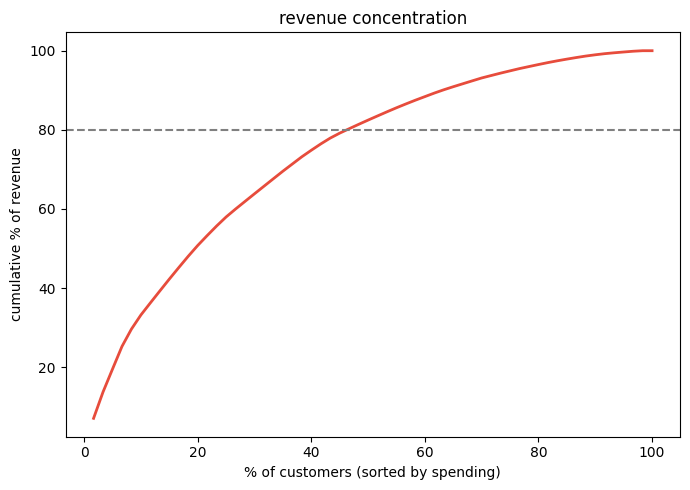

In [18]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(df_sorted['customer_pct'], df_sorted['cum_pct'], color='#e74c3c', linewidth=2)
ax.axhline(80, color='gray', linestyle='--')
ax.set_title('revenue concentration')
ax.set_xlabel('% of customers (sorted by spending)')
ax.set_ylabel('cumulative % of revenue')
plt.tight_layout()
plt.savefig('pareto.png', dpi=120)
plt.show()

## 8. CEO Dashboard

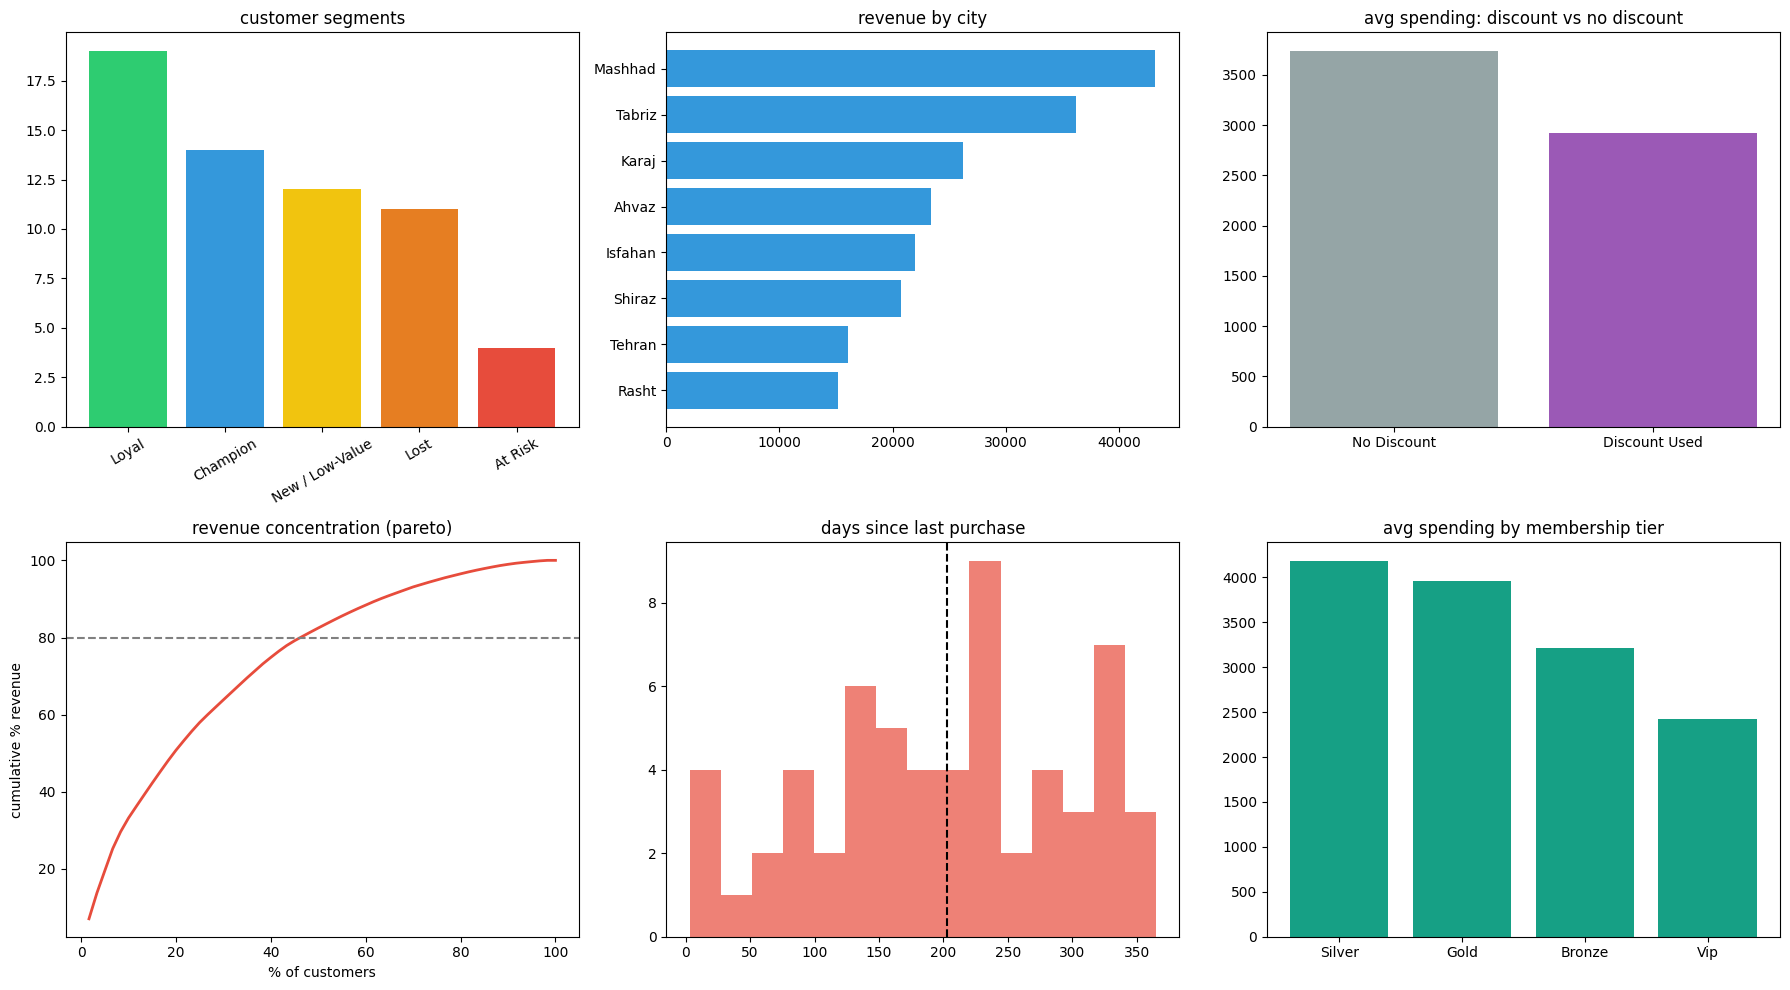

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

seg_counts = df['segment'].value_counts()
axes[0,0].bar(seg_counts.index, seg_counts.values, color=['#2ecc71','#3498db','#f1c40f','#e67e22','#e74c3c'])
axes[0,0].set_title('customer segments')
axes[0,0].tick_params(axis='x', rotation=30)

axes[0,1].barh(city_rev.index, city_rev.values, color='#3498db')
axes[0,1].set_title('revenue by city')
axes[0,1].invert_yaxis()

disc_avg = df.groupby('discount_used')['total_spending'].mean()
axes[0,2].bar(['No Discount', 'Discount Used'], disc_avg.values, color=['#95a5a6','#9b59b6'])
axes[0,2].set_title('avg spending: discount vs no discount')

axes[1,0].plot(df_sorted['customer_pct'], df_sorted['cum_pct'], color='#e74c3c', linewidth=2)
axes[1,0].axhline(80, color='gray', linestyle='--')
axes[1,0].set_title('revenue concentration (pareto)')
axes[1,0].set_xlabel('% of customers')
axes[1,0].set_ylabel('cumulative % revenue')

axes[1,1].hist(df['last_purchase_days'], bins=15, color='#e74c3c', alpha=0.7)
axes[1,1].axvline(df['last_purchase_days'].median(), color='black', linestyle='--')
axes[1,1].set_title('days since last purchase')

tier_avg = df.groupby('membership_tier')['total_spending'].mean().sort_values(ascending=False)
axes[1,2].bar(tier_avg.index, tier_avg.values, color='#16a085')
axes[1,2].set_title('avg spending by membership tier')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=120)
plt.show()

## 9. Three Recommendations

**1.** [win-back campaign for the At Risk group from section 5] - state the number of people and why they matter.

**2.** [something about discounts, based on section 7] - state what the data showed across spending, purchase count, order value, and satisfaction, and why this needs an actual test before assuming causation.

**3.** [city recommendation from section 6, plus something for the largest existing city] - state the reasoning and the customer count so the sample size is clear.

## 10. Limitations

- Small dataset (~60 customers) - segment and city results are a starting point, not solid proof.
- No order-level data, only totals per customer, so no way to see trends over time or which products actually drive sales.
- discount_used is Yes/No only, not an amount, so the discount analysis is limited to usage patterns rather than discount size.
- No statistical significance testing was performed, so differences between groups should be read as "worth investigating," not "confirmed."
- No data on income, product preferences, or acquisition channel, which would help sharpen these recommendations further.

In [20]:
df.to_csv('customer_segments.csv', index=False)
print('saved')

saved
